<a href="https://colab.research.google.com/github/AEzeekiel/Phishing-Detection/blob/main/phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.feature_selection import SelectFromModel

print("✅ Library berhasil diimport.")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   Scikit-learn digunakan")

✅ Library berhasil diimport.
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   Scikit-learn digunakan


In [ ]:
FILE_PATH = "PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(FILE_PATH)
print(f"   Jumlah baris   : {df.shape[0]:,}")
print(f"   Jumlah kolom   : {df.shape[1]:,}")
print(f"\n📋 5 baris pertama:")
df.head()

   Jumlah baris   : 235,795
   Jumlah kolom   : 55

📋 5 baris pertama:


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


  CELL 3 — EXPLORATORY DATA ANALYSIS (EDA)

📌 [3a] Info Tipe Data Setiap Kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64

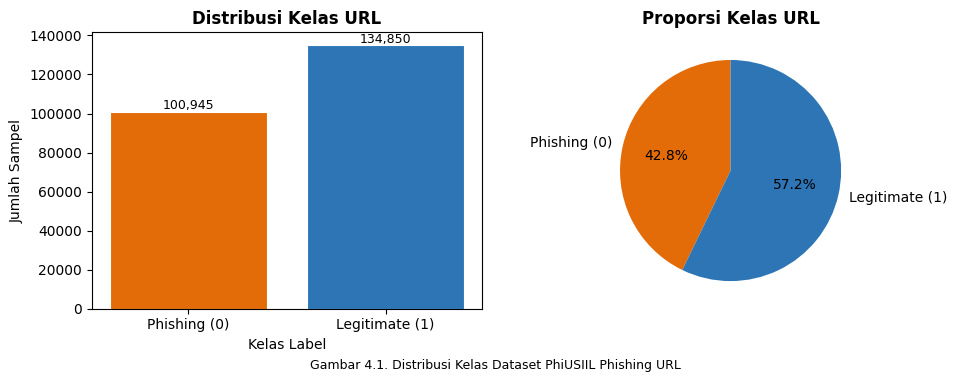

  ✅ Gambar 4.1 disimpan → gambar_4_1_distribusi_kelas.png

📌 [3d] Pemeriksaan Missing Value per Kolom:
  ✅ Tidak terdapat missing value pada dataset.


In [ ]:
TARGET_COL = 'label'

print("=" * 55)
print("  CELL 3 — EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 55)

# ── 3a. Info tipe data ────────────────────────────────────────
print("\n📌 [3a] Info Tipe Data Setiap Kolom:")
df.info()

# ── 3b. Distribusi label kelas ────────────────────────────────
print("\n📌 [3b] Distribusi Label Kelas:")

label_counts = df[TARGET_COL].value_counts().sort_index()
label_pct    = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

# mapping eksplisit biar gak kebalik
label_mapping = {
    0: 'Phishing (0)',
    1: 'Legitimate (1)'
}

dist_df = pd.DataFrame({
    'Jumlah': label_counts,
    'Persentase (%)': label_pct.round(2)
})

dist_df.index = [label_mapping[i] for i in dist_df.index]

print(dist_df.to_string())

# ── 3c. Visualisasi distribusi kelas ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = [label_mapping[i] for i in label_counts.index]

# Bar chart
axes[0].bar(
    labels,
    label_counts.values,
    color=['#E36C09', '#2E75B6'],  # sesuai urutan (0,1)
    edgecolor='white',
    linewidth=0.8
)

axes[0].set_title('Distribusi Kelas URL', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kelas Label')

# dynamic offset (lebih aman)
offset = max(label_counts.values) * 0.01

for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + offset, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=['#E36C09', '#2E75B6'],
    startangle=90
)

axes[1].set_title('Proporsi Kelas URL', fontweight='bold')

plt.suptitle(
    'Gambar 4.1. Distribusi Kelas Dataset PhiUSIIL Phishing URL',
    fontsize=9, y=0.02
)

plt.tight_layout()
plt.savefig('gambar_4_1_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✅ Gambar 4.1 disimpan → gambar_4_1_distribusi_kelas.png")

# ── 3d. Missing value ─────────────────────────────────────────
print("\n📌 [3d] Pemeriksaan Missing Value per Kolom:")

mv      = df.isnull().sum()
mv_pct  = (mv / len(df) * 100).round(2)

mv_df   = pd.DataFrame({
    'Jumlah Missing': mv,
    'Persen (%)': mv_pct
})

mv_df = mv_df[mv_df['Jumlah Missing'] > 0]

if mv_df.empty:
    print("  ✅ Tidak terdapat missing value pada dataset.")
else:
    print(mv_df.to_string())
    print("  ⚠️  Akan ditangani dengan imputation (bukan drop).")

In [ ]:
SELECTED_FEATURES = [
    # --- Leksikal (struktur URL) ---
    'URLLength',
    'DomainLength',
    'IsDomainIP',
    'CharContinuationRate',
    'TLDLength',
    'NoOfSubDomain',
    'HasObfuscation',
    'ObfuscationRatio',
    'LetterRatioInURL',
    'DegitRatioInURL',
    'SpacialCharRatioInURL',

    # --- Query structure ---
    'NoOfEqualsInURL',
    'NoOfQMarkInURL',
    'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL',

    # --- Protocol ---
    'IsHTTPS',

    # --- Page structure ---
    'LineOfCode',
    'LargestLineLength',
    'HasFavicon',
    'Robots',
    'IsResponsive',
    'NoOfURLRedirect',
    'NoOfSelfRedirect',
    'HasDescription',
    'NoOfPopup',
    'NoOfiFrame',
    'HasExternalFormSubmit',
    'HasSocialNet',
    'HasSubmitButton',
    'HasHiddenFields',
    'HasPasswordField',

    # --- Content indicators ---
    'Bank',
    'Pay',
    'Crypto',
    'HasCopyrightInfo',

    # --- Resource features ---
    'NoOfImage',
    'NoOfCSS',
    'NoOfJS',
    'NoOfSelfRef',
    'NoOfEmptyRef',
    'NoOfExternalRef'
]

available = [f for f in SELECTED_FEATURES if f in df.columns]
missing_feat = [f for f in SELECTED_FEATURES if f not in df.columns]

print("=" * 55)
print("  CELL 4 — FEATURE SELECTION")
print("=" * 55)

print(f"\n📌 Total fitur ditargetkan : {len(SELECTED_FEATURES)}")
print(f"   Fitur berhasil dipilih  : {len(available)}")

if missing_feat:
    print(f"   Fitur tidak ditemukan   : {len(missing_feat)}")
    print(f"   → {missing_feat}")

print(f"\n📌 Daftar fitur yang akan digunakan:")
for i, f in enumerate(available, 1):
    print(f"   {i:2d}. {f}")

# Validasi target
assert TARGET_COL in df.columns, (
    f"\n❌ Kolom target '{TARGET_COL}' tidak ditemukan di dataset!"
)

# 🚨 PENTING: pastikan label TIDAK masuk ke fitur
X_raw = df[available].copy()
y     = df[TARGET_COL].copy()

print(f"\n✅ Fitur (X) shape : {X_raw.shape}")
print(f"   Target (y) shape : {y.shape}")

print(f"\n📌 Distribusi label:")
print(f"   Legitimate (1) : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print(f"   Phishing   (0) : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")

  CELL 4 — FEATURE SELECTION

📌 Total fitur ditargetkan : 41
   Fitur berhasil dipilih  : 41

📌 Daftar fitur yang akan digunakan:
    1. URLLength
    2. DomainLength
    3. IsDomainIP
    4. CharContinuationRate
    5. TLDLength
    6. NoOfSubDomain
    7. HasObfuscation
    8. ObfuscationRatio
    9. LetterRatioInURL
   10. DegitRatioInURL
   11. SpacialCharRatioInURL
   12. NoOfEqualsInURL
   13. NoOfQMarkInURL
   14. NoOfAmpersandInURL
   15. NoOfOtherSpecialCharsInURL
   16. IsHTTPS
   17. LineOfCode
   18. LargestLineLength
   19. HasFavicon
   20. Robots
   21. IsResponsive
   22. NoOfURLRedirect
   23. NoOfSelfRedirect
   24. HasDescription
   25. NoOfPopup
   26. NoOfiFrame
   27. HasExternalFormSubmit
   28. HasSocialNet
   29. HasSubmitButton
   30. HasHiddenFields
   31. HasPasswordField
   32. Bank
   33. Pay
   34. Crypto
   35. HasCopyrightInfo
   36. NoOfImage
   37. NoOfCSS
   38. NoOfJS
   39. NoOfSelfRef
   40. NoOfEmptyRef
   41. NoOfExternalRef

✅ Fitur (X) shape :

In [ ]:
print("=" * 55)
print("  CELL 5 — DATA PREPROCESSING")
print("=" * 55)

# ── 5a. Penghapusan Duplikat ──────────────────────────────────
df_temp  = df[available + [TARGET_COL]].copy()

n_before = len(df_temp)

# drop duplicate berdasarkan seluruh fitur + label
df_clean = df_temp.drop_duplicates()

n_after  = len(df_clean)
n_dup    = n_before - n_after

print(f"\n📌 [5a] Penghapusan Data Duplikat:")
print(f"   Jumlah baris sebelum : {n_before:,}")
print(f"   Jumlah baris duplikat: {n_dup:,}")
print(f"   Jumlah baris sesudah : {n_after:,}")
print(f"   ✅ {n_dup:,} baris duplikat berhasil dihapus.")

# Split fitur dan target
X = df_clean[available].copy()
y = df_clean[TARGET_COL].copy()

# ── 5b. Verifikasi Missing Value (lebih detail) ───────────────
print(f"\n📌 [5b] Pemeriksaan Missing Value per Kolom:")

mv = X.isnull().sum()
mv = mv[mv > 0]

if mv.empty:
    print("   ✅ Tidak ada missing value — data siap diproses.")
else:
    print(mv.to_string())
    print("   ⚠️  Akan ditangani oleh SimpleImputer di pipeline model.")

# ── 5c. Konfirmasi Label Encoding ─────────────────────────────
print(f"\n📌 [5c] Konfirmasi Label Encoding:")

unique_labels = sorted(y.unique().tolist())
print(f"   Nilai unik label : {unique_labels}")

assert set(unique_labels) == {0, 1}, (
    "❌ Label tidak dalam format biner (0 dan 1)"
)

print(f"   1 = Legitimate   : {(y==1).sum():,} sampel ({(y==1).mean()*100:.1f}%)")
print(f"   0 = Phishing     : {(y==0).sum():,} sampel ({(y==0).mean()*100:.1f}%)")
print("   ✅ Label valid dan siap digunakan.")

# ── 5d. Stratified Train-Test Split (80:20) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n📌 [5d] Pembagian Data — Stratified Train-Test Split (80:20):")

print(f"   Training set : {X_train.shape[0]:,} sampel")
print(f"     Legitimate : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"     Phishing   : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")

print(f"\n   Testing set  : {X_test.shape[0]:,} sampel")
print(f"     Legitimate : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print(f"     Phishing   : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")

print("\n  ✅ Preprocessing selesai — data siap untuk pemodelan.")

  CELL 5 — DATA PREPROCESSING

📌 [5a] Penghapusan Data Duplikat:
   Jumlah baris sebelum : 235,795
   Jumlah baris duplikat: 39,348
   Jumlah baris sesudah : 196,447
   ✅ 39,348 baris duplikat berhasil dihapus.

📌 [5b] Pemeriksaan Missing Value per Kolom:
   ✅ Tidak ada missing value — data siap diproses.

📌 [5c] Konfirmasi Label Encoding:
   Nilai unik label : [0, 1]
   1 = Legitimate   : 134,819 sampel (68.6%)
   0 = Phishing     : 61,628 sampel (31.4%)
   ✅ Label valid dan siap digunakan.

📌 [5d] Pembagian Data — Stratified Train-Test Split (80:20):
   Training set : 157,157 sampel
     Legitimate : 107,855 (68.6%)
     Phishing   : 49,302 (31.4%)

   Testing set  : 39,290 sampel
     Legitimate : 26,964 (68.6%)
     Phishing   : 12,326 (31.4%)

  ✅ Preprocessing selesai — data siap untuk pemodelan.


In [ ]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    # Mengisi missing value dengan median (robust terhadap outlier)
])

print("=" * 55)
print("  CELL 6 — PIPELINE PREPROCESSOR SIAP")
print("=" * 55)

print("\n  Tahap 1 — SimpleImputer")
print("    strategy = 'median'")
print("    → Mengisi missing value dengan nilai median tiap kolom")

print("\n  ℹ️  StandardScaler tidak digunakan")
print("    → Model Decision Tree & Random Forest tidak membutuhkan scaling")

print("\n  ✅ Preprocessor siap digunakan dalam pipeline model.")

  CELL 6 — PIPELINE PREPROCESSOR SIAP

  Tahap 1 — SimpleImputer
    strategy = 'median'
    → Mengisi missing value dengan nilai median tiap kolom

  ℹ️  StandardScaler tidak digunakan
    → Model Decision Tree & Random Forest tidak membutuhkan scaling

  ✅ Preprocessor siap digunakan dalam pipeline model.


In [ ]:
print("=" * 55)
print("  CELL 7 — EMBEDDED FEATURE SELECTION")
print("=" * 55)

# Apply preprocessing dulu
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Train model untuk ambil importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train_prep, y_train)

# Feature importance
importances = rf_temp.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n📌 Top 10 Feature Importance:")
print(feat_imp.head(10))

# Select fitur pakai threshold median
selector = SelectFromModel(rf_temp, threshold='median', prefit=True)

X_train_sel = selector.transform(X_train_prep)
X_test_sel  = selector.transform(X_test_prep)

selected_features = X_train.columns[selector.get_support()]

print(f"\n📌 Jumlah fitur sebelum : {X_train.shape[1]}")
print(f"📌 Jumlah fitur sesudah : {X_train_sel.shape[1]}")

print("\n📌 Fitur terpilih:")
for f in selected_features:
    print(f" - {f}")

  CELL 7 — EMBEDDED FEATURE SELECTION

📌 Top 10 Feature Importance:
                       Feature  Importance
40             NoOfExternalRef    0.171276
16                  LineOfCode    0.142551
38                 NoOfSelfRef    0.114157
37                      NoOfJS    0.094657
27                HasSocialNet    0.074178
35                   NoOfImage    0.066685
36                     NoOfCSS    0.051985
14  NoOfOtherSpecialCharsInURL    0.051119
0                    URLLength    0.028984
17           LargestLineLength    0.028844

📌 Jumlah fitur sebelum : 41
📌 Jumlah fitur sesudah : 21

📌 Fitur terpilih:
 - URLLength
 - CharContinuationRate
 - NoOfSubDomain
 - LetterRatioInURL
 - DegitRatioInURL
 - SpacialCharRatioInURL
 - NoOfOtherSpecialCharsInURL
 - IsHTTPS
 - LineOfCode
 - LargestLineLength
 - IsResponsive
 - HasDescription
 - HasSocialNet
 - HasSubmitButton
 - HasCopyrightInfo
 - NoOfImage
 - NoOfCSS
 - NoOfJS
 - NoOfSelfRef
 - NoOfEmptyRef
 - NoOfExternalRef


In [ ]:
print("=" * 55)
print("  CELL 7 — DECISION TREE — HYPERPARAMETER TUNING")
print("=" * 55)

# Hyperparameter grid
param_grid_dt = {
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy'],
}

# Model langsung (tanpa pipeline)
dt = DecisionTreeClassifier(random_state=42)

# 10-Fold Stratified CV
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

total_combinations = (
    len(param_grid_dt['max_depth']) *
    len(param_grid_dt['min_samples_split']) *
    len(param_grid_dt['min_samples_leaf']) *
    len(param_grid_dt['criterion'])
)

print(f"\n📌 Total kombinasi hyperparameter : {total_combinations}")
print(f"   Total fit dijalankan          : {total_combinations * 10}")

print("\n⏳ Menjalankan GridSearchCV Decision Tree...\n")

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring='f1_weighted',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# 🚨 PENTING: pakai hasil feature selection
grid_dt.fit(X_train_sel, y_train)

best_dt = grid_dt.best_estimator_

print(f"\n{'─'*50}")
print("  ✅ GridSearchCV Decision Tree Selesai")
print(f"{'─'*50}")

print("  Hyperparameter Terbaik:")
for k, v in grid_dt.best_params_.items():
    print(f"    {k:<25}: {v}")

print(f"\n  Best CV F1-Score (weighted): {grid_dt.best_score_:.4f} "
      f"({grid_dt.best_score_*100:.2f}%)")

print("\n  ℹ️ Model siap untuk evaluasi di test set.")

  CELL 7 — DECISION TREE — HYPERPARAMETER TUNING

📌 Total kombinasi hyperparameter : 90
   Total fit dijalankan          : 900

⏳ Menjalankan GridSearchCV Decision Tree...

Fitting 10 folds for each of 90 candidates, totalling 900 fits

──────────────────────────────────────────────────
  ✅ GridSearchCV Decision Tree Selesai
──────────────────────────────────────────────────
  Hyperparameter Terbaik:
    criterion                : entropy
    max_depth                : 20
    min_samples_leaf         : 2
    min_samples_split        : 2

  Best CV F1-Score (weighted): 0.9991 (99.91%)

  ℹ️ Model siap untuk evaluasi di test set.


In [ ]:
print("=" * 55)
print("  CELL 8 — RANDOM FOREST — HYPERPARAMETER TUNING")
print("=" * 55)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, None],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2'],
    'criterion'        : ['gini'],
}

# Model langsung (tanpa pipeline)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)

# Hitung total kombinasi
total_combinations_rf = (
    len(param_grid_rf['n_estimators']) *
    len(param_grid_rf['max_depth']) *
    len(param_grid_rf['min_samples_split']) *
    len(param_grid_rf['max_features']) *
    len(param_grid_rf['criterion'])
)

print(f"\n📌 Total kombinasi hyperparameter : {total_combinations_rf}")
print(f"   Total fit dijalankan          : {total_combinations_rf * 10}")

print("\n⏳ Menjalankan GridSearchCV Random Forest...\n")

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1_weighted',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# 🚨 PENTING: pakai hasil feature selection
grid_rf.fit(X_train_sel, y_train)

best_rf = grid_rf.best_estimator_

print(f"\n{'─'*50}")
print("  ✅ GridSearchCV Random Forest Selesai")
print(f"{'─'*50}")

print("  Hyperparameter Terbaik:")
for k, v in grid_rf.best_params_.items():
    print(f"    {k:<25}: {v}")

print(f"\n  Best CV F1-Score (weighted): {grid_rf.best_score_:.4f} "
      f"({grid_rf.best_score_*100:.2f}%)")

print("\n  ℹ️ Model siap untuk dibandingkan dengan Decision Tree.")

  CELL 8 — RANDOM FOREST — HYPERPARAMETER TUNING

📌 Total kombinasi hyperparameter : 16
   Total fit dijalankan          : 160

⏳ Menjalankan GridSearchCV Random Forest...

Fitting 10 folds for each of 16 candidates, totalling 160 fits

──────────────────────────────────────────────────
  ✅ GridSearchCV Random Forest Selesai
──────────────────────────────────────────────────
  Hyperparameter Terbaik:
    criterion                : gini
    max_depth                : None
    max_features             : sqrt
    min_samples_split        : 5
    n_estimators             : 100

  Best CV F1-Score (weighted): 0.9999 (99.99%)

  ℹ️ Model siap untuk dibandingkan dengan Decision Tree.


In [ ]:
print("=" * 55)
print("  CELL 9 — EVALUASI MODEL — TESTING SET")
print("=" * 55)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluasi model pada testing set
    pos_label=0 → phishing sebagai kelas positif
    """
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"\n{'═'*50}")
    print(f"  {model_name}")
    print(f"{'═'*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  ({prec*100:.2f}%)")
    print(f"  Recall    : {rec:.4f}  ({rec*100:.2f}%)")
    print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")

    print(f"\n  Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=['Phishing (0)', 'Legitimate (1)']
    ))

    return {
        'Model'    : model_name,
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1-Score' : f1,
        'CM'       : cm,
        'y_pred'   : y_pred,
    }

# 🚨 PENTING: pakai X_test_sel (hasil feature selection)
results_dt = evaluate_model(best_dt, X_test_sel, y_test, "Decision Tree (Baseline)")
results_rf = evaluate_model(best_rf, X_test_sel, y_test, "Random Forest (Utama)")

# ── Ringkasan perbandingan ───────────────────────────────────
results_df = pd.DataFrame([
    {k: v for k, v in results_dt.items() if k not in ['CM', 'y_pred']},
    {k: v for k, v in results_rf.items() if k not in ['CM', 'y_pred']}
])

print("\n📊 Ringkasan Perbandingan Model:")
print(results_df.to_string(index=False))


  CELL 9 — EVALUASI MODEL — TESTING SET

══════════════════════════════════════════════════
  Decision Tree (Baseline)
══════════════════════════════════════════════════
  Accuracy  : 0.9991  (99.91%)
  Precision : 0.9983  (99.83%)
  Recall    : 0.9987  (99.87%)
  F1-Score  : 0.9985  (99.85%)

  Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     12326
Legitimate (1)       1.00      1.00      1.00     26964

      accuracy                           1.00     39290
     macro avg       1.00      1.00      1.00     39290
  weighted avg       1.00      1.00      1.00     39290


══════════════════════════════════════════════════
  Random Forest (Utama)
══════════════════════════════════════════════════
  Accuracy  : 0.9998  (99.98%)
  Precision : 0.9998  (99.98%)
  Recall    : 0.9994  (99.94%)
  F1-Score  : 0.9996  (99.96%)

  Classification Report:
                precision    recall  f1-score   support

  Phish

  CELL 10 — CONFUSION MATRIX — VISUALISASI


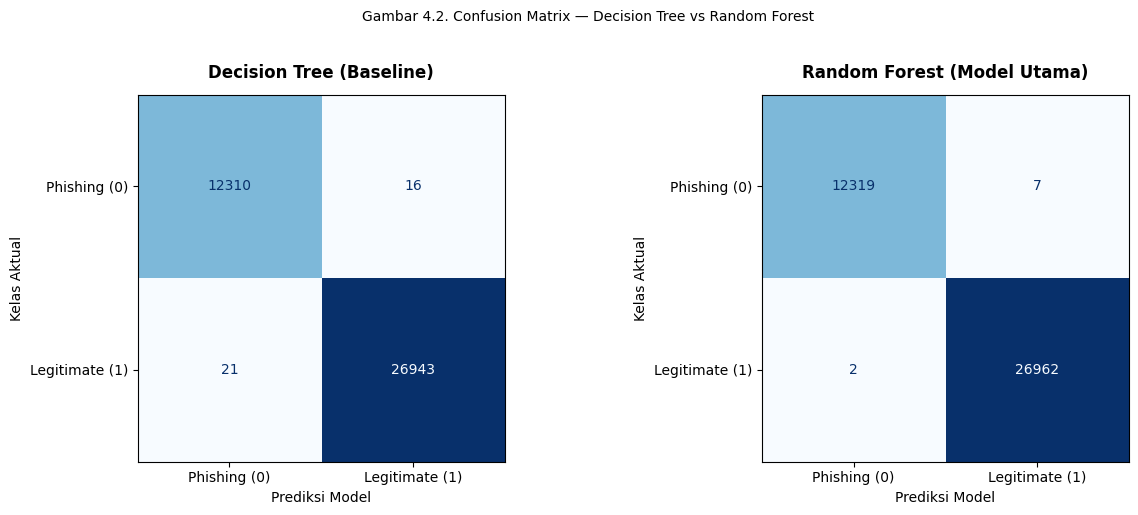

  ✅ Gambar 4.2 disimpan → gambar_4_2_confusion_matrix.png

──────────────────────────────────────────────────
  Rincian Komponen Confusion Matrix
──────────────────────────────────────────────────

  Decision Tree (Baseline):
    ✅ TP — Phishing  → Phishing   : 12,310
    ❌ FN — Phishing  → Legitimate :     16  (0.13%)
    ⚠️  FP — Legitimate → Phishing  :     21
    ✅ TN — Legitimate → Legitimate : 26,943

  Random Forest (Utama):
    ✅ TP — Phishing  → Phishing   : 12,319
    ❌ FN — Phishing  → Legitimate :      7  (0.06%)
    ⚠️  FP — Legitimate → Phishing  :      2
    ✅ TN — Legitimate → Legitimate : 26,962


In [ ]:
print("=" * 55)
print("  CELL 10 — CONFUSION MATRIX — VISUALISASI")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, title in zip(
    axes,
    [results_dt, results_rf],
    ['Decision Tree (Baseline)', 'Random Forest (Model Utama)']
):
    cm = res['CM']

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Phishing (0)', 'Legitimate (1)']
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d'   # 🔥 tampilkan angka integer
    )

    ax.set_title(title, fontweight='bold', pad=12)
    ax.set_xlabel('Prediksi Model', fontsize=10)
    ax.set_ylabel('Kelas Aktual', fontsize=10)

plt.suptitle(
    'Gambar 4.2. Confusion Matrix — Decision Tree vs Random Forest',
    fontsize=10, y=1.02
)

plt.tight_layout()
plt.savefig('gambar_4_2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✅ Gambar 4.2 disimpan → gambar_4_2_confusion_matrix.png")

# ── Detail komponen TP / FN / FP / TN ────────────────────────
print(f"\n{'─'*50}")
print(f"  Rincian Komponen Confusion Matrix")
print(f"{'─'*50}")

for res in [results_dt, results_rf]:
    cm = res['CM']

    TP = cm[0][0]
    FN = cm[0][1]
    FP = cm[1][0]
    TN = cm[1][1]

    fn_rate = FN / (TP + FN) * 100 if (TP + FN) > 0 else 0

    print(f"\n  {res['Model']}:")
    print(f"    ✅ TP — Phishing  → Phishing   : {TP:>6,}")
    print(f"    ❌ FN — Phishing  → Legitimate : {FN:>6,}  ({fn_rate:.2f}%)")
    print(f"    ⚠️  FP — Legitimate → Phishing  : {FP:>6,}")
    print(f"    ✅ TN — Legitimate → Legitimate : {TN:>6,}")

In [ ]:
print("=" * 55)
print("  CELL 11 — TABEL PERBANDINGAN PERFORMA")
print("=" * 55)

comparison = pd.DataFrame([
    {
        'Model'        : 'Decision Tree (Baseline)',
        'Accuracy (%)' : round(results_dt['Accuracy']  * 100, 4),
        'Precision (%)': round(results_dt['Precision'] * 100, 4),
        'Recall (%)'   : round(results_dt['Recall']    * 100, 4),
        'F1-Score (%)' : round(results_dt['F1-Score']  * 100, 4),
    },
    {
        'Model'        : 'Random Forest (Utama)',
        'Accuracy (%)' : round(results_rf['Accuracy']  * 100, 4),
        'Precision (%)': round(results_rf['Precision'] * 100, 4),
        'Recall (%)'   : round(results_rf['Recall']    * 100, 4),
        'F1-Score (%)' : round(results_rf['F1-Score']  * 100, 4),
    },
]).set_index('Model')

print(f"\n📊 Tabel Perbandingan Performa Model:")
print(f"\n{comparison.to_string()}")

# Selisih performa
diff = comparison.loc['Random Forest (Utama)'] - comparison.loc['Decision Tree (Baseline)']

print(f"\n📌 Selisih RF minus DT:")
for col in comparison.columns:
    print(f"   {col:<15}: {diff[col]:+.4f}%")

# Interpretasi otomatis
print("\n📌 Interpretasi:")
if (diff.abs() < 0.1).all():
    print("   Perbedaan performa sangat kecil (<0.1%) → kedua model hampir setara.")
else:
    print("   Terdapat perbedaan performa yang cukup signifikan antar model.")

  CELL 11 — TABEL PERBANDINGAN PERFORMA

📊 Tabel Perbandingan Performa Model:

                          Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Model                                                                          
Decision Tree (Baseline)       99.9058        99.8297     99.8702       99.8499
Random Forest (Utama)          99.9771        99.9838     99.9432       99.9635

📌 Selisih RF minus DT:
   Accuracy (%)   : +0.0713%
   Precision (%)  : +0.1541%
   Recall (%)     : +0.0730%
   F1-Score (%)   : +0.1136%

📌 Interpretasi:
   Terdapat perbedaan performa yang cukup signifikan antar model.


  CELL 12 — BAR CHART PERBANDINGAN PERFORMA


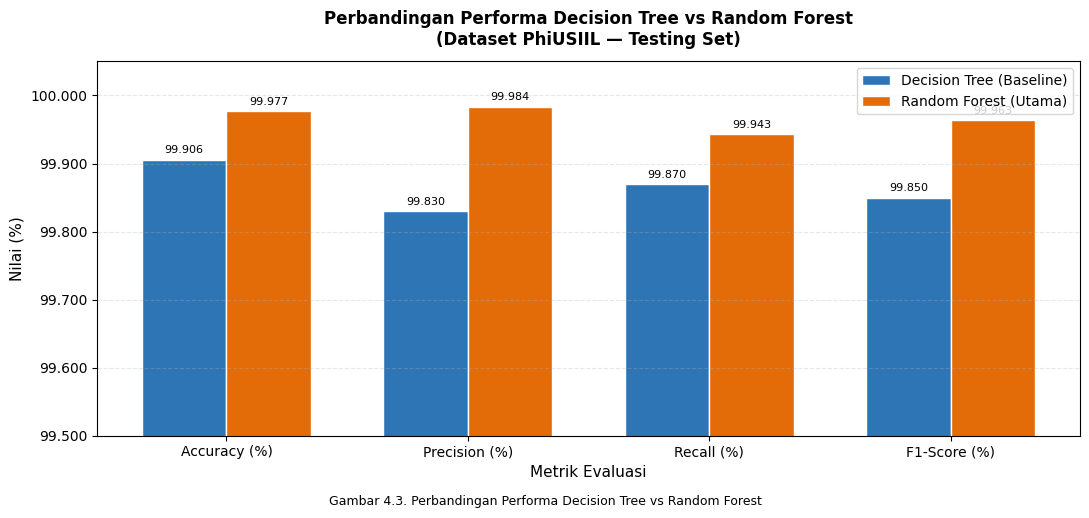

  ✅ Gambar 4.3 disimpan → gambar_4_3_perbandingan_performa.png


In [ ]:
print("=" * 55)
print("  CELL 12 — BAR CHART PERBANDINGAN PERFORMA")
print("=" * 55)

metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(
    x - width/2,
    [comparison.loc['Decision Tree (Baseline)', m] for m in metrics],
    width, label='Decision Tree (Baseline)',
    color='#2E75B6', edgecolor='white'
)

bars2 = ax.bar(
    x + width/2,
    [comparison.loc['Random Forest (Utama)', m] for m in metrics],
    width, label='Random Forest (Utama)',
    color='#E36C09', edgecolor='white'
)

ax.set_xlabel('Metrik Evaluasi', fontsize=11)
ax.set_ylabel('Nilai (%)', fontsize=11)

ax.set_title(
    'Perbandingan Performa Decision Tree vs Random Forest\n'
    '(Dataset PhiUSIIL — Testing Set)',
    fontweight='bold', pad=12
)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)

# 🔥 FIX: zoom ke range tinggi biar jujur tapi tetap jelas
ax.set_ylim(99.5, 100.05)

ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Label angka
for bar in list(bars1) + list(bars2):
    ax.annotate(
        f'{bar.get_height():.3f}',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3), textcoords='offset points',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()

fig.text(
    0.5, -0.02,
    'Gambar 4.3. Perbandingan Performa Decision Tree vs Random Forest',
    ha='center', fontsize=9
)

plt.savefig('gambar_4_3_perbandingan_performa.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✅ Gambar 4.3 disimpan → gambar_4_3_perbandingan_performa.png")

  CELL 13 — FEATURE IMPORTANCE

📌 [13a] Feature Importance — Random Forest (Top 15):
 Rank                      Fitur  Importance  Kontribusi (%)
    1            NoOfExternalRef    0.193029          19.303
    2                 LineOfCode    0.188777          18.878
    3                NoOfSelfRef    0.125747          12.575
    4                  NoOfImage    0.125054          12.505
    5 NoOfOtherSpecialCharsInURL    0.072476           7.248
    6                    NoOfCSS    0.056433           5.643
    7                     NoOfJS    0.049645           4.964
    8               HasSocialNet    0.030721           3.072
    9           HasCopyrightInfo    0.027195           2.720
   10                  URLLength    0.022152           2.215
   11             HasDescription    0.022078           2.208
   12            DegitRatioInURL    0.019896           1.990
   13           LetterRatioInURL    0.016103           1.610
   14                    IsHTTPS    0.015645           1.565


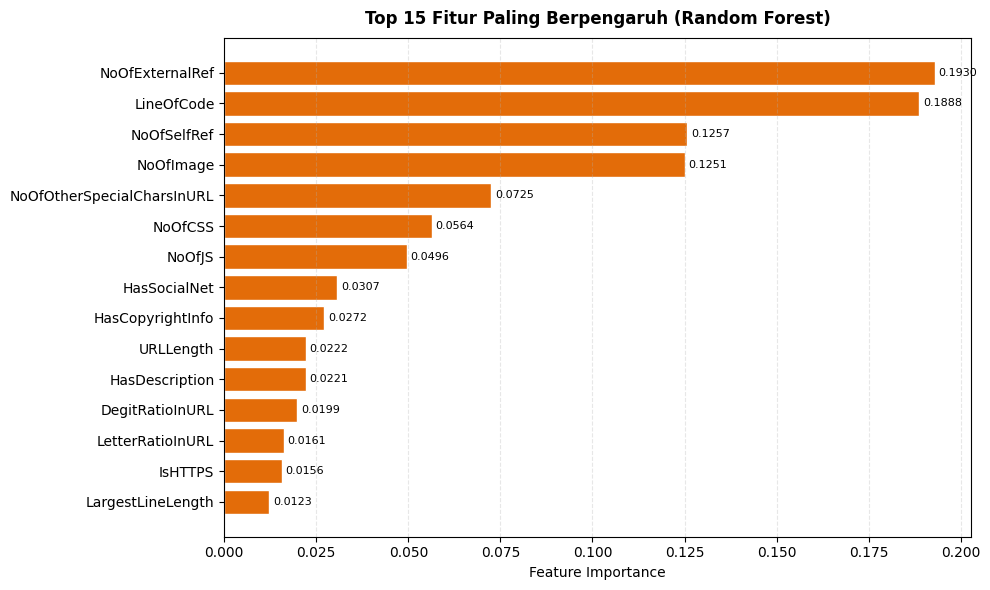


📌 [13b] Feature Importance — Decision Tree (Top 15):
 Rank                      Fitur  Importance  Kontribusi (%)
    1            NoOfExternalRef    0.728575          72.858
    2                NoOfSelfRef    0.088921           8.892
    3 NoOfOtherSpecialCharsInURL    0.077360           7.736
    4                 LineOfCode    0.046347           4.635
    5                    IsHTTPS    0.033889           3.389
    6              NoOfSubDomain    0.011098           1.110
    7           LetterRatioInURL    0.003503           0.350
    8            DegitRatioInURL    0.002539           0.254
    9                  URLLength    0.002192           0.219
   10       CharContinuationRate    0.001923           0.192
   11                  NoOfImage    0.000839           0.084
   12          LargestLineLength    0.000742           0.074
   13      SpacialCharRatioInURL    0.000566           0.057
   14             HasDescription    0.000475           0.047
   15                     NoOfJ

In [ ]:
print("=" * 55)
print("  CELL 13 — FEATURE IMPORTANCE")
print("=" * 55)

# 🚨 pakai fitur hasil selection
# X_train_sel is a numpy array and does not have a .columns attribute.
# The `selected_features` variable was already correctly defined in cell `iyvnn6EH_NVa`.
# selected_features = X_train_sel.columns.tolist()

# ── Random Forest ─────────────────────────
rf_clf = best_rf

fi_df = pd.DataFrame({
    'Fitur'      : selected_features,
    'Importance' : rf_clf.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_df['Rank'] = fi_df.index + 1
fi_df['Kontribusi (%)'] = (fi_df['Importance'] * 100).round(3)

print("\n📌 [13a] Feature Importance — Random Forest (Top 15):")
print(fi_df[['Rank','Fitur','Importance','Kontribusi (%)']].head(15).to_string(index=False))

# Visualisasi RF
top15_rf = fi_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top15_rf['Fitur'][::-1],
    top15_rf['Importance'][::-1],
    color='#E36C09', edgecolor='white'
)

ax.set_xlabel('Feature Importance', fontsize=10)
ax.set_title(
    'Top 15 Fitur Paling Berpengaruh (Random Forest)',
    fontweight='bold', pad=10
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=8
    )

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('gambar_4_4a_feature_importance_rf.png', dpi=150)
plt.show()

# ── Decision Tree ─────────────────────────
dt_clf = best_dt

fi_dt_df = pd.DataFrame({
    'Fitur'      : selected_features,
    'Importance' : dt_clf.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fi_dt_df['Rank'] = fi_dt_df.index + 1
fi_dt_df['Kontribusi (%)'] = (fi_dt_df['Importance'] * 100).round(3)

print("\n📌 [13b] Feature Importance — Decision Tree (Top 15):")
print(fi_dt_df[['Rank','Fitur','Importance','Kontribusi (%)']].head(15).to_string(index=False))

In [ ]:
print("=" * 55)
print("  CELL 14 — ANALISIS FALSE NEGATIVE")
print("=" * 55)

y_pred_dt = results_dt['y_pred']
y_pred_rf = results_rf['y_pred']

# Mask FN
fn_mask_dt = (y_test.values == 0) & (y_pred_dt == 1)
fn_mask_rf = (y_test.values == 0) & (y_pred_rf == 1)

# Mask TP
tp_mask_rf = (y_test.values == 0) & (y_pred_rf == 0)

total_phishing_test = (y_test.values == 0).sum()

print("\n📌 [14a] Jumlah & Rate False Negative:")
print(f"   Total phishing test : {total_phishing_test:,}")

for name, mask in [('Decision Tree', fn_mask_dt), ('Random Forest', fn_mask_rf)]:
    fn_count = mask.sum()
    fn_rate  = fn_count / total_phishing_test * 100
    print(f"\n   {name}:")
    print(f"     FN Count : {fn_count:,}")
    print(f"     FN Rate  : {fn_rate:.4f}%")

# ☢️ pakai X_test_sel
fn_rf_feat = X_test_sel[fn_mask_rf]
tp_rf_feat = X_test_sel[tp_mask_rf]

compare_fn = pd.DataFrame({
    'FN_avg': fn_rf_feat.mean(axis=0),
    'TP_avg': tp_rf_feat.mean(axis=0),
}, index=selected_features)

compare_fn['Selisih'] = (compare_fn['FN_avg'] - compare_fn['TP_avg']).abs()
compare_fn = compare_fn.sort_values('Selisih', ascending=False)

print("\n📌 [14b] Perbandingan FN vs TP (Random Forest):")
print(compare_fn.head(10).round(4).to_string())

print("\n📌 [14c] Interpretasi:")
top3 = compare_fn.head(3).index.tolist()
print(f"   Fitur paling membedakan: {top3}")

  CELL 14 — ANALISIS FALSE NEGATIVE

📌 [14a] Jumlah & Rate False Negative:
   Total phishing test : 12,326

   Decision Tree:
     FN Count : 16
     FN Rate  : 0.1298%

   Random Forest:
     FN Count : 7
     FN Rate  : 0.0568%

📌 [14b] Perbandingan FN vs TP (Random Forest):
                                 FN_avg      TP_avg      Selisih
LargestLineLength           169350.7143  32261.8070  137088.9072
LineOfCode                     665.8571     82.4682     583.3889
URLLength                       30.7143     52.6996      21.9853
NoOfExternalRef                 14.0000      1.3773      12.6227
NoOfJS                          10.5714      1.2641       9.3074
NoOfSelfRef                      6.1429      0.6952       5.4477
NoOfCSS                          5.4286      0.6173       4.8113
NoOfImage                        4.4286      1.2053       3.2233
NoOfOtherSpecialCharsInURL       1.4286      4.5348       3.1062
HasSubmitButton                  0.8571      0.1262       0.7309

📌 [14c

  CELL 15 — ROC CURVE — VISUALISASI
  ✈️ Decision Tree (Baseline)
     AUC = 0.9991  (99.91%)
  ✈️ Random Forest (Utama)
     AUC = 1.0000  (100.00%)


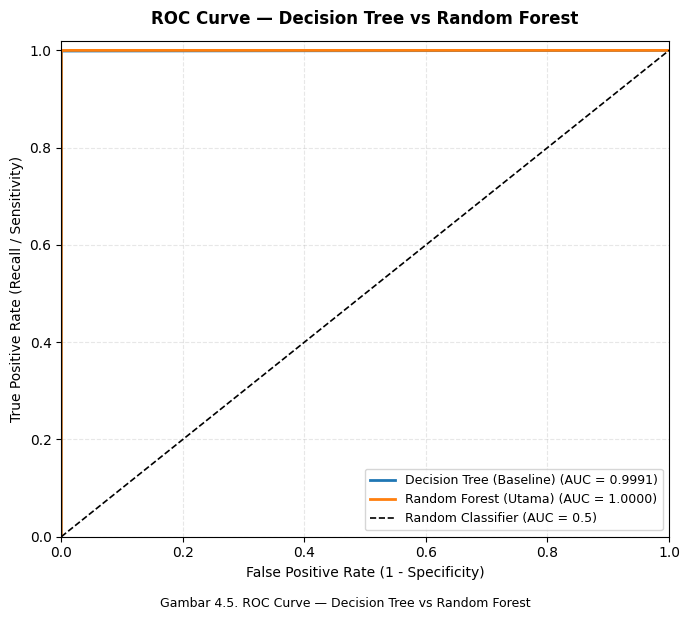


  ✅ Gambar 4.5 disimpan → gambar_4_5_roc_curve.png


In [ ]:
print("=" * 55)
print("  CELL 15 — ROC CURVE — VISUALISASI")
print("=" * 55)

fig, ax = plt.subplots(figsize=(7, 6))

for model, label, color in [
    (best_dt, 'Decision Tree (Baseline)', '#2E75B6'),
    (best_rf, 'Random Forest (Utama)',    '#E36C09'),
]:
    # Ambil probabilitas kelas POSITIF (phishing = 0)
    # → kita tetap eksplisit biar ga ambigu
    y_prob = model.predict_proba(X_test_sel)

    # Ambil probabilitas untuk kelas phishing (0)
    # Cari index kelas 0 secara eksplisit (lebih aman)
    class_index = list(model.classes_).index(0)
    y_prob_phishing = y_prob[:, class_index]

    fpr, tpr, _ = roc_curve(y_test, y_prob_phishing, pos_label=0)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        label=f'{label} (AUC = {roc_auc:.4f})',
        lw=2
    )

    print(f"  ✈️ {label}")
    print(f"     AUC = {roc_auc:.4f}  ({roc_auc*100:.2f}%)")

# Garis random classifier
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=10)
ax.set_title('ROC Curve — Decision Tree vs Random Forest', fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
fig.text(
    0.5, -0.02,
    'Gambar 4.5. ROC Curve — Decision Tree vs Random Forest',
    ha='center', fontsize=9
)
plt.savefig('gambar_4_5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  ✅ Gambar 4.5 disimpan → gambar_4_5_roc_curve.png")

In [ ]:
print("=" * 55)
print("  CELL 16 — 10-FOLD CROSS-VALIDATION — SUMMARY")
print("=" * 55)

from sklearn.metrics import make_scorer

# Custom scorer → phishing (0) sebagai positive class
precision_phishing = make_scorer(precision_score, pos_label=0)
recall_phishing    = make_scorer(recall_score, pos_label=0)
f1_phishing        = make_scorer(f1_score, pos_label=0)

scoring_metrics = {
    'accuracy' : 'accuracy',
    'precision': precision_phishing,
    'recall'   : recall_phishing,
    'f1'       : f1_phishing,
}

# ⚠️ PENTING: pakai pipeline ulang, JANGAN best_model
pipeline_dt_cv = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(
        criterion='entropy',
        max_depth=20,
        min_samples_leaf=2,
        min_samples_split=2,
        random_state=42
    ))
])

pipeline_rf_cv = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        max_features='sqrt',
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

for model, name in [
    (pipeline_dt_cv, 'Decision Tree (Baseline)'),
    (pipeline_rf_cv, 'Random Forest (Utama)'),
]:
    print(f"\n📌 {name}:")

    cv_res = cross_validate(
        model, X, y,
        cv=cv_strategy,
        scoring=scoring_metrics,
        n_jobs=-1,
    )

    for metric in scoring_metrics:
        scores = cv_res[f'test_{metric}']
        print(
            f"   {metric.capitalize():<12}: "
            f"{scores.mean()*100:.2f}% "
            f"± {scores.std()*100:.2f}%  "
            f"[min: {scores.min()*100:.2f}%, max: {scores.max()*100:.2f}%]"
        )

  CELL 16 — 10-FOLD CROSS-VALIDATION — SUMMARY

📌 Decision Tree (Baseline):
   Accuracy    : 99.91% ± 0.02%  [min: 99.88%, max: 99.94%]
   Precision   : 99.83% ± 0.04%  [min: 99.76%, max: 99.89%]
   Recall      : 99.89% ± 0.03%  [min: 99.84%, max: 99.94%]
   F1          : 99.86% ± 0.03%  [min: 99.81%, max: 99.90%]

📌 Random Forest (Utama):
   Accuracy    : 99.98% ± 0.01%  [min: 99.96%, max: 99.99%]
   Precision   : 99.98% ± 0.01%  [min: 99.97%, max: 100.00%]
   Recall      : 99.96% ± 0.03%  [min: 99.89%, max: 100.00%]
   F1          : 99.97% ± 0.02%  [min: 99.94%, max: 99.99%]


In [ ]:
print("=" * 55)
print("  CELL 17 — SIMPAN SEMUA HASIL")
print("=" * 55)

import os

OUTPUT_DIR = "hasil_penelitian"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Perbandingan Model ────────────────────────────────────
if 'comparison' in globals():
    comparison.to_csv(f'{OUTPUT_DIR}/hasil_perbandingan_model.csv')
    print("  ✅ hasil_perbandingan_model.csv disimpan")
else:
    print("  ⚠️ comparison tidak ditemukan — skip")

# ── 2. Feature Importance ────────────────────────────────────
if 'fi_df' in globals():
    fi_df[['Rank','Fitur','Importance','Kontribusi (%)']].to_csv(
        f'{OUTPUT_DIR}/feature_importance_rf.csv', index=False
    )
    print("  ✅ feature_importance_rf.csv disimpan")

if 'fi_dt_df' in globals():
    fi_dt_df[['Rank','Fitur','Importance','Kontribusi (%)']].to_csv(
        f'{OUTPUT_DIR}/feature_importance_dt.csv', index=False
    )
    print("  ✅ feature_importance_dt.csv disimpan")

# ── 3. False Negative Analysis ───────────────────────────────
if 'compare_fn' in globals():
    compare_fn.to_csv(f'{OUTPUT_DIR}/analisis_false_negative_rf.csv')
    print("  ✅ analisis_false_negative_rf.csv disimpan")

# ── 4. Simpan Best Parameter ─────────────────────────────────
if 'grid_dt' in globals():
    pd.DataFrame([grid_dt.best_params_]).to_csv(
        f'{OUTPUT_DIR}/best_params_dt.csv', index=False
    )
    print("  ✅ best_params_dt.csv disimpan")

if 'grid_rf' in globals():
    pd.DataFrame([grid_rf.best_params_]).to_csv(
        f'{OUTPUT_DIR}/best_params_rf.csv', index=False
    )
    print("  ✅ best_params_rf.csv disimpan")

# ── 5. Ringkasan ROC AUC ─────────────────────────────────────
roc_summary = []

for model, name in [
    (best_dt, 'Decision Tree'),
    (best_rf, 'Random Forest')
]:
    y_prob = model.predict_proba(X_test_sel)
    class_index = list(model.classes_).index(0)
    y_prob_phishing = y_prob[:, class_index]

    fpr, tpr, _ = roc_curve(y_test, y_prob_phishing, pos_label=0)
    roc_auc = auc(fpr, tpr)

    roc_summary.append({
        'Model': name,
        'AUC': roc_auc
    })

pd.DataFrame(roc_summary).to_csv(
    f'{OUTPUT_DIR}/roc_auc_summary.csv', index=False
)
print("  ✅ roc_auc_summary.csv disimpan")

# ── SUMMARY OUTPUT ───────────────────────────────────────────
print(f"""
{'═'*55}
  RINGKASAN OUTPUT PENELITIAN
{'═'*55}

  📊 FILE CSV:
  ┌─ hasil_perbandingan_model.csv
  ├─ feature_importance_rf.csv
  ├─ feature_importance_dt.csv
  ├─ analisis_false_negative_rf.csv
  ├─ best_params_dt.csv
  ├─ best_params_rf.csv
  └─ roc_auc_summary.csv

  🖼  FILE GAMBAR:
  ┌─ gambar_4_1_distribusi_kelas.png
  ├─ gambar_4_2_confusion_matrix.png
  ├─ gambar_4_3_perbandingan_performa.png
  ├─ gambar_4_4a_feature_importance_rf.png
  ├─ gambar_4_4b_feature_importance_dt.png
  └─ gambar_4_5_roc_curve.png

  📁 Semua file tersimpan di folder: {OUTPUT_DIR}

{'═'*55}
""")

  CELL 17 — SIMPAN SEMUA HASIL
  ✅ hasil_perbandingan_model.csv disimpan
  ✅ feature_importance_rf.csv disimpan
  ✅ feature_importance_dt.csv disimpan
  ✅ analisis_false_negative_rf.csv disimpan
  ✅ best_params_dt.csv disimpan
  ✅ best_params_rf.csv disimpan
  ✅ roc_auc_summary.csv disimpan

═══════════════════════════════════════════════════════
  RINGKASAN OUTPUT PENELITIAN
═══════════════════════════════════════════════════════

  📊 FILE CSV:
  ┌─ hasil_perbandingan_model.csv
  ├─ feature_importance_rf.csv
  ├─ feature_importance_dt.csv
  ├─ analisis_false_negative_rf.csv
  ├─ best_params_dt.csv
  ├─ best_params_rf.csv
  └─ roc_auc_summary.csv

  🖼  FILE GAMBAR:
  ┌─ gambar_4_1_distribusi_kelas.png
  ├─ gambar_4_2_confusion_matrix.png
  ├─ gambar_4_3_perbandingan_performa.png
  ├─ gambar_4_4a_feature_importance_rf.png
  ├─ gambar_4_4b_feature_importance_dt.png
  └─ gambar_4_5_roc_curve.png

  📁 Semua file tersimpan di folder: hasil_penelitian

═══════════════════════════════════════